Fluids Lab 2

In [ ]:
import scipy.io as sio
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def compute_from_mat(mat_path: Path):
    """Return (filename, cp[24], Cd, Cl, Po, Ps). None if variable P/V missing."""
    d = sio.loadmat(str(mat_path), squeeze_me=True, struct_as_record=False, simplify_cells=True)
    P = d.get("P"); V = d.get("V")
    if P is None or V is None:
        return None
    
    Po = np.mean(P[:, 0])     # adjust indices to your schema
    Ps = np.mean(P[:, 1])
    U  = np.mean(V)
    rho = 1.225
    kin_visc = 1.46e-5
    Re = (rho * U * 0.15875) / kin_visc  # not used later, but OK to keep

    cp    = np.zeros(24)
    P_cyl = np.zeros(24)
    D     = np.zeros(24)
    L     = np.zeros(24)

    for i in range(3, 27):  # i=3..26 (24 taps)
        if np.shape(P) == (100, 26):
            i -= 1
        radians     = (i - 3) * np.pi / 12  # 15° steps
        P_cyl[i-3]  = np.mean(P[:, i])
        cp[i-3]     = (P_cyl[i-3] - Ps) / (Po - Ps)

        F_r = P_cyl[i-3] * 0.15875 * np.pi / 24  # scalar for this tap
        D[i-3] = -F_r * np.cos(radians)
        L[i-3] =  F_r * np.sin(radians)

    D_tot = D.sum()
    L_tot = L.sum()
    Cd = D_tot / ((Po - Ps) * 0.15875)
    Cl = L_tot / ((Po - Ps) * 0.15875)

    return mat_path.name, cp, Cd, Cl, Po, Ps

def download_mat(path_pattern: str):
    """Return first match for path_pattern, or None if not found."""
    matches = list(Path.cwd().glob(f"**/{path_pattern}"))
    return matches[0] if matches else None

_, cp, Cd, Cl, Po, Ps = compute_from_mat("S2G1RPM300STRIP.mat")

Find Cp

[-1.35992268 -1.34774624 -1.31619111 -1.29224021 -1.28918051 -1.27511311
 -1.31396294 -1.44247466 -0.85396594 -0.06619407  0.63261715  0.98292956
  0.85133598  0.24075577 -0.48557492 -1.24076393 -1.49170846 -1.28420853
 -1.28735922 -1.31634333 -1.34201637 -1.36650825 -1.11508266 -1.40952512]


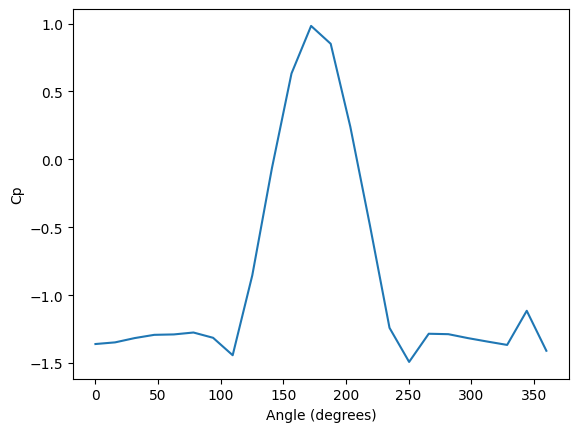

In [3]:
def find_cp(P):
    cp = np.zeros(24)
    Po = np.average(P[:,0])
    Ps = np.average(P[:,1])
    for i in range(3,27):
        cp[i-3] = (np.average(P[:,i]) - Ps)/(Po - Ps)
    return cp
cp = find_cp(P)
print(cp)
degrees = np.linspace(0, 360, 24)
plt.plot(degrees, cp)
plt.xlabel('Angle (degrees)')
plt.ylabel('Cp')
plt.show()

Find 